In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Facemask_Dataset.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP file extracted successfully!")

ZIP file extracted successfully!


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
img_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "/content/Facemask_Dataset",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_data = datagen.flow_from_directory(
    "/content/Facemask_Dataset",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",
    shuffle=True
)

Found 6043 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.


In [8]:
print(train_data.class_indices)

{'with_mask': 0, 'without_mask': 1}


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


124/189 ━━━━━━━━━━━━━━━━━━━━ 40s 617ms/step - accuracy: 0.7363 - loss: 0.5099

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 ━━━━━━━━━━━━━━━━━━━━ 139s 727ms/step - accuracy: 0.7696 - loss: 0.4636 - val_accuracy: 0.9318 - val_loss: 0.2188
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 131s 690ms/step - accuracy: 0.8996 - loss: 0.2527 - val_accuracy: 0.9272 - val_loss: 0.2059
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 128s 677ms/step - accuracy: 0.9253 - loss: 0.2060 - val_accuracy: 0.9179 - val_loss: 0.1959
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 127s 674ms/step - accuracy: 0.9377 - loss: 0.1643 - val_accuracy: 0.9563 - val_loss: 0.1325
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 126s 668ms/step - accuracy: 0.9515 - loss: 0.1379 - val_accuracy: 0.9556 - val_loss: 0.1216
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 132s 701ms/step - accuracy: 0.9653 - loss: 0.0934 - val_accuracy: 0.9358 - val_loss: 0.1587
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 129s 681ms/step - accuracy: 0.9667 - loss: 0.0864 - val_accuracy: 0.9623 - val_loss: 0.1164
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 128s 675ms/step - accuracy: 0.9763 - loss: 0.06

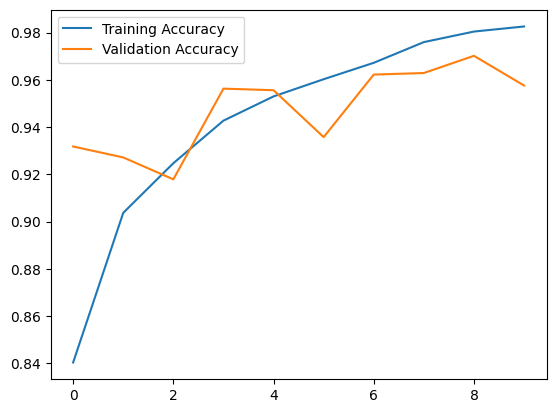

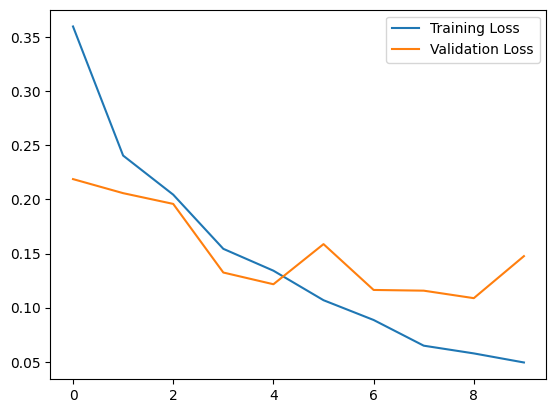

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [20]:
#TEST ON ANOTHER DIFFERENT DATASET


test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/test",
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_data)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

Found 337 images belonging to 2 classes.
11/11 ━━━━━━━━━━━━━━━━━━━━ 75s 7s/step - accuracy: 0.9305 - loss: 0.2513
Test Accuracy: 0.9169139266014099
Test Loss: 0.3141637146472931


In [22]:
import numpy as np

predictions = model.predict(test_data)
predicted_classes = (predictions > 0.5).astype(int)

true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

#Picked 10 random:
random_indices = np.random.choice(len(true_classes), size=10, replace=False)

for i in random_indices:
    print(
        f"Index {i}: "
        f"True = {class_labels[true_classes[i]]}, "
        f"Predicted = {class_labels[predicted_classes[i][0]]}"
    )

11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 528ms/step
Index 293: True = without_mask, Predicted = without_mask
Index 270: True = without_mask, Predicted = without_mask
Index 57: True = with_mask, Predicted = with_mask
Index 295: True = without_mask, Predicted = without_mask
Index 323: True = without_mask, Predicted = without_mask
Index 39: True = with_mask, Predicted = with_mask
Index 147: True = with_mask, Predicted = with_mask
Index 246: True = without_mask, Predicted = without_mask
Index 335: True = without_mask, Predicted = without_mask
Index 83: True = with_mask, Predicted = with_mask
